# Final project for Machine Learning

This is supervised learning using Random Forest Classifier in the NBA dataset to determine the winning team.

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from matplotlib import rcParams
import warnings

warnings.filterwarnings("ignore")
np.random.seed(42)


In [11]:
game = pd.read_csv("data/game.csv")


In [71]:
teams = pd.read_csv("data/team.csv")

In [72]:
game_df = pd.merge(game, teams, how="left", left_on="team_id_home", right_on="id", suffixes=("_home", "_team_home"))
game_df = pd.merge(game_df, teams, how="left", left_on="team_id_away", right_on="id", suffixes=("_away", "_team_away"))

In [73]:
game_df.head()

,season_id,team_id_home,team_abbreviation_home,team_name_home,game_id,game_date,matchup_home,wl_home,min,fgm_home,...,city_away,state_away,year_founded_away,id_team_away,full_name_team_away,abbreviation_team_away,nickname_team_away,city_team_away,state_team_away,year_founded_team_away
0,21946,1610610035,HUS,Toronto Huskies,24600001,1946-11-01 00:00:00,HUS vs. NYK,L,0,25.0,...,NaN,NaN,NaN,1.610613e+09,New York Knicks,NYK,Knicks,New York,New York,1946.0
1,21946,1610610034,BOM,St. Louis Bombers,24600003,1946-11-02 00:00:00,BOM vs. PIT,W,0,20.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,21946,1610610032,PRO,Providence Steamrollers,24600002,1946-11-02 00:00:00,PRO vs. BOS,W,0,21.0,...,NaN,NaN,NaN,1.610613e+09,Boston Celtics,BOS,Celtics,Boston,Massachusetts,1946.0
3,21946,1610610025,CHS,Chicago Stags,24600004,1946-11-02 00:00:00,CHS vs. NYK,W,0,21.0,...,NaN,NaN,NaN,1.610613e+09,New York Knicks,NYK,Knicks,New York,New York,1946.0
4,21946,1610610028,DEF,Detroit Falcons,24600005,1946-11-02 00:00:00,DEF vs. WAS,L,0,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [75]:
game_df['home_team_win'] = game_df['wl_home'].apply(lambda x: 1 if x == 'W' else 0)

In [76]:
features = ['fgm_home', 'fga_home', 'fg_pct_home', 'fg3m_home', 'fg3a_home', 'fg_pct_home',
            'ftm_home', 'fta_home', 'ft_pct_home', 'oreb_home', 'dreb_home', 'reb_home',
            'ast_home', 'stl_home', 'blk_home', 'tov_home', 'pf_home', 'pts_home',
            'fgm_away', 'fga_away', 'fg_pct_away', 'fg3m_away', 'fg3a_away', 'fg_pct_away',
            'ftm_away', 'fta_away', 'ft_pct_away', 'oreb_away', 'dreb_away', 'reb_away', 'ast_away',
            'stl_away', 'blk_away', 'tov_away', 'pf_away', 'pts_away']

In [77]:
X = game_df[features]
y = game_df['home_team_win']

In [78]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [79]:

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, stratify=y, test_size=0.10, random_state=42
)

In [80]:
# create the classifier
classifier = RandomForestClassifier(n_estimators=100)

# Train the model using the training sets
classifier.fit(X_train, y_train)

RandomForestClassifier()

In [61]:
y_pred = classifier.predict(X_test)

In [62]:
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.9828006088280061


In [63]:
# check Important features
feature_importances_df = pd.DataFrame(
    {"feature": list(X.columns), "importance": classifier.feature_importances_}
).sort_values("importance", ascending=False)

# Display
feature_importances_df

,feature,importance
17,pts_home,0.196152
35,pts_away,0.193207
18,fgm_away,0.058564
0,fgm_home,0.054341
2,fg_pct_home,0.053775
5,fg_pct_home,0.051779
20,fg_pct_away,0.048105
23,fg_pct_away,0.045374
6,ftm_home,0.030472
24,ftm_away,0.025898


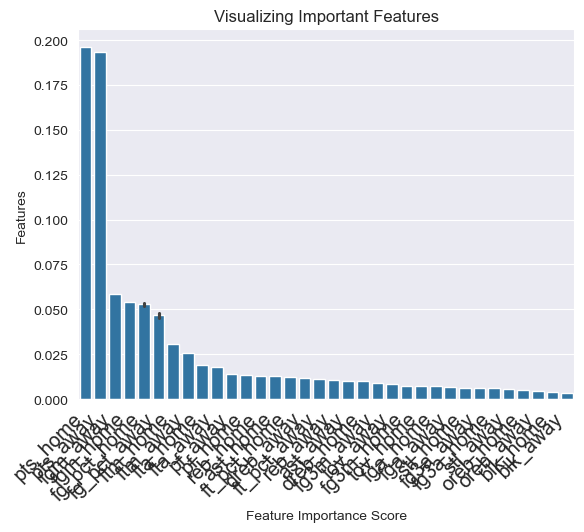

In [64]:
# visualize important featuers

# Creating a bar plot
sns.barplot(x=feature_importances_df.feature, y=feature_importances_df.importance)
# Add labels to your

plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Visualizing Important Features")
plt.xticks(
    rotation=45, horizontalalignment="right", fontweight="light", fontsize="x-large"
)
plt.show()

In [65]:
# load data with selected features
X = game_df[features]

X = X.drop(['fg3a_away', 'fg3a_home', 'oreb_home', 'oreb_away', 'blk_home', 'blk_away', 'fg3m_away', 'tov_away', 'tov_home', 'fg3m_home', 'fga_home', 'fga_away', 'stl_home', 'stl_away'], axis=1)
y = game_df['home_team_win']

# standardize the dataset
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# split into train and test set
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, stratify=y, test_size=0.10, random_state=42
)

In [70]:
# Create a Random Classifier
clf = RandomForestClassifier(n_estimators=470)

# Train the model using the training sets
clf.fit(X_train, y_train)

# prediction on test set
y_pred = clf.predict(X_test)

# Calculate Model Accuracy,
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9875190258751902
